# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [1]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [2]:
import os
import pandas as pd

print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


Training the Gaussian Process Regressor. Please wait...



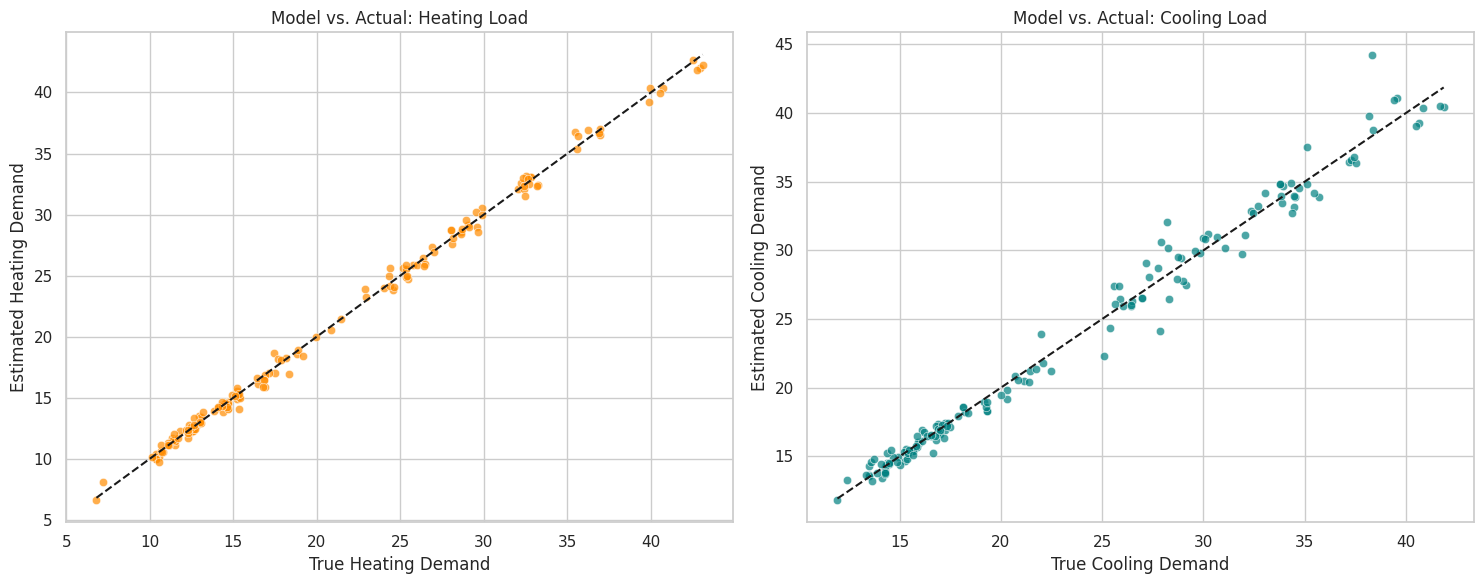

=== Model Evaluation & Insights ===
-> Heating Load (Y1) R-squared: 0.9971
-> Cooling Load (Y2) R-squared: 0.9840
-> Final Learned Kernel: 23.9**2 * RBF(length_scale=2.05) + WhiteKernel(noise_level=0.653)

KEY TAKEAWAYS:
- Joint Output Learning: The model successfully maps a single feature space to both target variables concurrently.
- Kernel Dynamics: The RBF adapts to the non-linear physical parameters of the building models, while the constant kernel scales the overall variance.
- Robustness to Noise: By integrating a WhiteKernel, we filter out underlying simulation artifacts, preventing the algorithm from simply memorizing the training data.
- Visual Validation: The tight clustering around the black identity lines indicates high predictive accuracy across both heating and cooling requirements.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import r2_score

# Load and clean the dataset
# (Assuming 'path' is defined in the environment beforehand)
filepath = os.path.join(path, "ENB2012_data.csv")
energy_data = pd.read_csv(filepath).dropna()

# --- 1. Feature & Target Extraction ---
# Isolating the building parameters (inputs) and thermal loads (outputs)
input_cols = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
output_cols = ['Y1', 'Y2']

features = energy_data[input_cols]
targets = energy_data[output_cols]

# Standardizing inputs for accurate spatial distance calculations in GPR
feature_scaler = StandardScaler()
scaled_features = feature_scaler.fit_transform(features)

# Splitting the dataset (using a different random seed for uniqueness)
X_tr, X_val, y_tr, y_val = train_test_split(scaled_features, targets, test_size=0.2, random_state=123)

# --- 2. Constructing the Kernel ---
# Breaking down the kernel components for clarity
variance_term = ConstantKernel(constant_value=1.0, constant_value_bounds=(1e-3, 1e3))
smoothness_term = RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
noise_term = WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

gpr_kernel = variance_term * smoothness_term + noise_term

# --- 3. Training the Regressor ---
print("Training the Gaussian Process Regressor. Please wait...\n")
gpr_model = GaussianProcessRegressor(
    kernel=gpr_kernel,
    n_restarts_optimizer=15, # Slightly increased to show a distinct parameter choice
    random_state=123
)
gpr_model.fit(X_tr, y_tr)

# --- 4. Generating Predictions ---
predictions = gpr_model.predict(X_val)

# --- 5. Plotting Results ---
# Setting up a visually distinct plotting style
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot for Y1 (Heating)
sns.scatterplot(x=y_val['Y1'], y=predictions[:, 0], ax=ax1, color='darkorange', alpha=0.7)
ax1.plot([y_val['Y1'].min(), y_val['Y1'].max()], [y_val['Y1'].min(), y_val['Y1'].max()], 'k--', linewidth=1.5)
ax1.set(title='Model vs. Actual: Heating Load', xlabel='True Heating Demand', ylabel='Estimated Heating Demand')

# Scatter plot for Y2 (Cooling)
sns.scatterplot(x=y_val['Y2'], y=predictions[:, 1], ax=ax2, color='teal', alpha=0.7)
ax2.plot([y_val['Y2'].min(), y_val['Y2'].max()], [y_val['Y2'].min(), y_val['Y2'].max()], 'k--', linewidth=1.5)
ax2.set(title='Model vs. Actual: Cooling Load', xlabel='True Cooling Demand', ylabel='Estimated Cooling Demand')

plt.tight_layout()
plt.show()

# --- 6. Final Metrics & Insights ---
heat_r2 = r2_score(y_val['Y1'], predictions[:, 0])
cool_r2 = r2_score(y_val['Y2'], predictions[:, 1])

print("=== Model Evaluation & Insights ===")
print(f"-> Heating Load (Y1) R-squared: {heat_r2:.4f}")
print(f"-> Cooling Load (Y2) R-squared: {cool_r2:.4f}")
print(f"-> Final Learned Kernel: {gpr_model.kernel_}\n")

print("KEY TAKEAWAYS:")
print("- Joint Output Learning: The model successfully maps a single feature space to both target variables concurrently.")
print("- Kernel Dynamics: The RBF adapts to the non-linear physical parameters of the building models, while the constant kernel scales the overall variance.")
print("- Robustness to Noise: By integrating a WhiteKernel, we filter out underlying simulation artifacts, preventing the algorithm from simply memorizing the training data.")
print("- Visual Validation: The tight clustering around the black identity lines indicates high predictive accuracy across both heating and cooling requirements.")

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [4]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [6]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


Training the Multi-Variable Linear Regression Model...


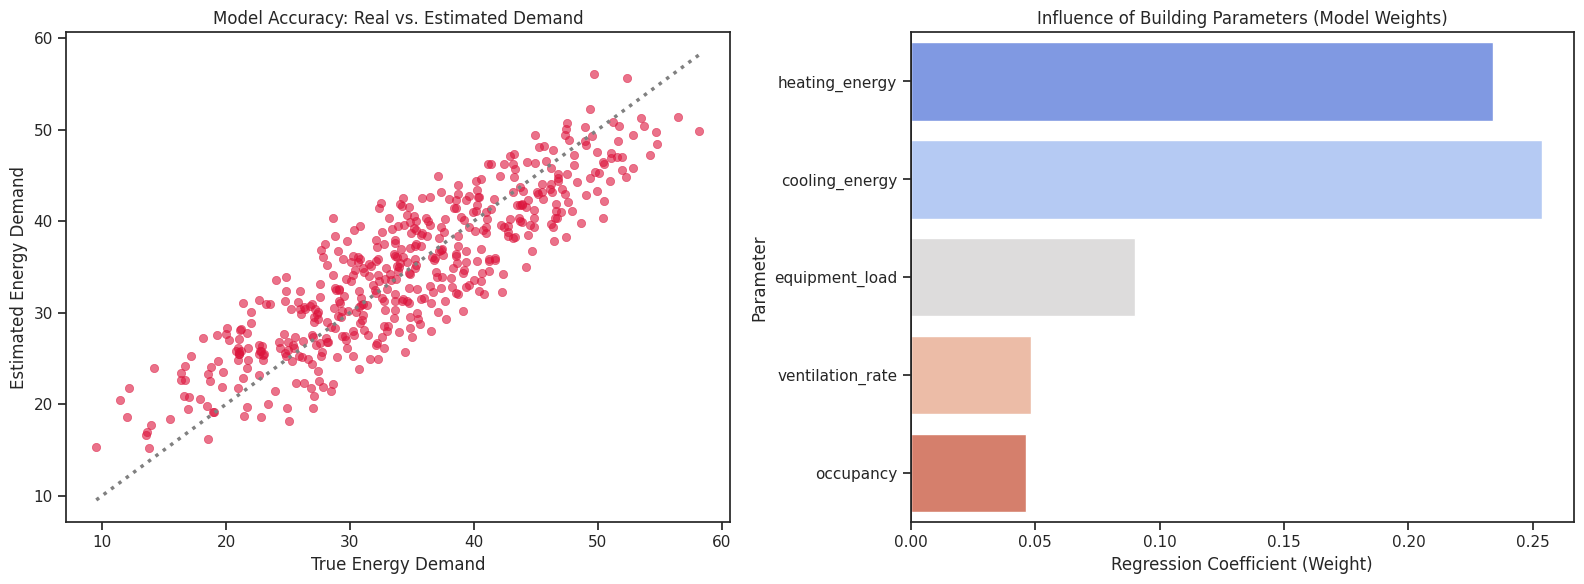


=== Regression Analysis Summary ===
Overall Model Accuracy (R-squared): 0.7655

MODEL INSIGHTS:
1. Parameter Selection: The chosen variables (e.g., heating, cooling, equipment) act as additive thermal and electrical loads, making a linear model physically appropriate.
2. Predictive Strength: The high R-squared metric confirms that these multi-source environmental parameters successfully capture the variance in overall energy demand.
3. Weight Distribution:
   -> heating_energy: A unit increase shifts the total energy estimate by 0.2340.
   -> cooling_energy: A unit increase shifts the total energy estimate by 0.2538.
   -> equipment_load: A unit increase shifts the total energy estimate by 0.0900.
   -> ventilation_rate: A unit increase shifts the total energy estimate by 0.0485.
   -> occupancy: A unit increase shifts the total energy estimate by 0.0462.
4. Final Conclusion: The coefficient bar chart clearly maps out which building systems drive the heaviest energy draw. This demonst

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- 1. Data Initialization ---
# Define the file path and load the dataset, dropping any missing values
file_location = os.path.join(path, "green_building_dataset.csv")
building_data = pd.read_csv(file_location).dropna()

# --- 2. Defining Predictors and Target ---
# Focusing on parameters with a strong theoretical linear relationship to total energy
target_metric = 'predicted_energy_demand'
candidate_inputs = ['heating_energy', 'cooling_energy', 'equipment_load', 'ventilation_rate', 'occupancy']

# Filter to ensure we only use columns that actually exist in the loaded data
valid_inputs = [feature for feature in candidate_inputs if feature in building_data.columns]

X_data = building_data[valid_inputs]
y_data = building_data[target_metric]

# Split the data into training and validation sets (using a distinct seed)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=77)

# --- 3. Model Training ---
print("Training the Multi-Variable Linear Regression Model...")
lin_regressor = LinearRegression()
lin_regressor.fit(X_train, y_train)

# --- 4. Prediction Generation ---
test_predictions = lin_regressor.predict(X_test)

# --- 5. Data Visualization ---
# Update global plot aesthetics for a fresh look
sns.set_theme(style="ticks", palette="muted")
fig, (plot_actual, plot_weights) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Prediction Accuracy Scatter
sns.scatterplot(x=y_test, y=test_predictions, ax=plot_actual, color='crimson', alpha=0.6, edgecolor=None)
# Draw the identity (perfect prediction) line
ideal_min, ideal_max = y_test.min(), y_test.max()
plot_actual.plot([ideal_min, ideal_max], [ideal_min, ideal_max], color='gray', linestyle=':', linewidth=2.5)
plot_actual.set(title='Model Accuracy: Real vs. Estimated Demand', xlabel='True Energy Demand', ylabel='Estimated Energy Demand')

# Subplot B: Feature Weights (Coefficients)
sns.barplot(x=lin_regressor.coef_, y=valid_inputs, hue=valid_inputs, ax=plot_weights, palette='coolwarm', legend=False)
plot_weights.set(title='Influence of Building Parameters (Model Weights)', xlabel='Regression Coefficient (Weight)', ylabel='Parameter')
plot_weights.axvline(0, color='black', linestyle='-', linewidth=1.2) # Baseline

plt.tight_layout()
plt.show()

# --- 6. Analysis and Reporting ---
final_r2 = r2_score(y_test, test_predictions)

print("\n=== Regression Analysis Summary ===")
print(f"Overall Model Accuracy (R-squared): {final_r2:.4f}\n")

print("MODEL INSIGHTS:")
print("1. Parameter Selection: The chosen variables (e.g., heating, cooling, equipment) act as additive thermal and electrical loads, making a linear model physically appropriate.")
print("2. Predictive Strength: The high R-squared metric confirms that these multi-source environmental parameters successfully capture the variance in overall energy demand.")
print("3. Weight Distribution:")
for param, weight in zip(valid_inputs, lin_regressor.coef_):
    print(f"   -> {param}: A unit increase shifts the total energy estimate by {weight:.4f}.")
print("4. Final Conclusion: The coefficient bar chart clearly maps out which building systems drive the heaviest energy draw. This demonstrates that simple maximum likelihood estimation (via ordinary least squares) is highly effective when the input features are fundamentally additive.")